[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/streamfunction_2D.ipynb)


# LEARNING OBJECTIVE

After exploring this notebook, you will be able to calculate the streamfunction $\psi(x,y)$ for a 2D planar flow given the components of the velocity $v_x(x,y)$ and $v_y(x,y)$, including how to automate this step using symbolic computing tools from SymPy. You will also build intuition for the streamfunction, and the various relationships between the streamfunction and the velocity profile, through flow visualization using Matplotlib.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [32]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *
from IPython.display import display, Math

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# STREAMFUNCTIONS FOR 2D PLANAR FLOWS

Consider the steady 2D planar flow:
$$
  \underline{v} = \big( v_x(x,y), v_y(x,y), 0 \big).
$$
If the flow is incompressible, $\nabla\cdot\underline{v}=0$, then the two velocity components can be expressed in terms of a _streamfunction_ $\psi(x,y)$ as
$$
  v_x = \partial_y \psi,\qquad v_y = -\partial_x \psi.
$$

In this notebook, we'll learn how to use streamfunctions, in conjunction with the vector field (flow) visualization tools of [Matplotlib](https://matplotlib.org/stable/gallery/index.html).

## Set $v_x$, $v_y$ and make a quiver plot

We will use [SymPy](https://docs.sympy.org/latest/tutorial/index.html) to symbolically define and manipulate the expressions. Then, [lambdify](https://docs.sympy.org/latest/modules/utilities/lambdify.html) our functions for numerical evaluation.

In [33]:
x, y, C = sp.symbols('x y C')
vx = sp.Function('vx')(x, y)
vy = sp.Function('vy')(x, y)
psi = sp.Function('psi')(x, y)
F = sp.Function('F')

Example velocity fields (execute only the cell you want; if you "Run All" then only the last velocity field applies).

You can also write your own velocity field but _make sure it is divergence free_, and make sure all your variables/functions are defined as SymPy symbols/functions at this point.


In [34]:
# ideal stagnation point
vx = x
vy = -y

In [35]:
# solid body rotation
vx = 2*y
vy = -2*x

In [36]:
# something I made up, looks cool and has interesting vorticity
# writing fractions like 3/2 as sp.Rational(3,2) 
# tells SymPy to carry through the fractions in all calculations below
#vx = (- 2*x**2 + 3*y**3 - 1)*sp.Rational(1,15) + 1
vx = (- 2*x**2 + 3*y**3 - 1)*sp.Rational(1,30) + sp.Rational(3,2)
vy = sp.integrate(-vx.diff(x),y) + sp.Rational(1,2)

In [37]:
# Taylor--Green vortex
vx = sp.sin(x) * sp.cos(y)
vy = -sp.cos(x) * sp.sin(y)

In [38]:
# a cool velocity field based on the Taylor--Green vortex
vx = 4*sp.sin(x)*sp.cos(y) - sp.cos(x)*sp.sin(y)
vy = -4*sp.cos(x)*sp.sin(y) + sp.sin(x)*sp.cos(y)

In [39]:
# check that the chosen flow field is incompressible, 
# otherwise there is no streamfunction
div_v = sp.simplify(vx.diff(x) + vy.diff(y))
if div_v != 0:
    raise ValueError('The chosen flow field is not incompressible, there is no streamfunction!')
else:
    display(Math(r'\text{Good news!}\;\; \nabla \cdot \vec{v} = ' 
                 + sp.latex(div_v) 
                 + r'~~~\checkmark'))

<IPython.core.display.Math object>

In [40]:
# finally, 'lambdify' the velocity components for number evaluation

# gracefully handle case when vx or vy is constant (independent of x, y)
# lambdify doesn't know what do if the function doesn't depend on the variables,
# so just returning an array of the same shape as x, filled with the constant value
depends_on_xy = len(vx.free_symbols.intersection({x, y})) > 0
if depends_on_xy:
    lam_vx = sp.lambdify([x, y], vx)
else:
    def lam_vx(x,y):
        return np.full_like(x, fill_value=vx)

depends_on_xy = len(vy.free_symbols.intersection({x, y})) > 0
if depends_on_xy:
    lam_vy = sp.lambdify([x, y], vy)
else:
    def lam_vy(x,y):
        return np.full_like(x, fill_value=vy)

First, we can visualize the given flow field using a [`quiver`](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_simple_demo.html) plot.


In [41]:
# define the meshgrid and range once for all subsequent plots
max = 5
xp, yp = np.meshgrid(np.linspace(-max, max, num=201),
                     np.linspace(-max, max, num=201))

# define a skip number for quiver plots, to avoid overcrowding
nskip = 15

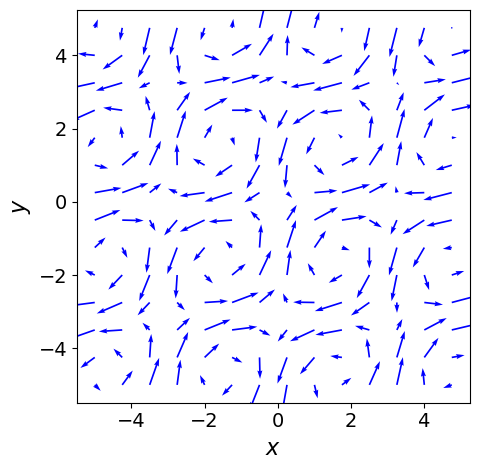

In [42]:
fig, ax = plt.subplots(tight_layout=True)

ax.quiver(xp[::nskip, ::nskip], yp[::nskip, ::nskip], 
          lam_vx(xp, yp)[::nskip, ::nskip], lam_vy(xp, yp)[::nskip, ::nskip],
          scale=max, scale_units='xy',  # scale controls arrow size, can be a number like 2
          color='blue')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

plt.show()

## Construct $\psi$

To construct $\psi$, we will use [SymPy](https://docs.sympy.org/latest/tutorial/index.html) and its relationship to the velocity components (given).

Specifically, we

1.   undo the $y$ derivative in $\partial_y \psi = v_x$ via an indefinite integral (adding an arbitrary _function_ of integration) as $\psi(x,y) = \int v_x \, dy + F(x)$,
2.   substitute the later into $\partial_x \psi = -v_y$ to obtain $\int \frac{\partial v_x}{\partial x}\, dy + F'(x) = -v_y$,
3.   solve the equation from step 2 as an ODE for $F(x)$ given $v_x(x,y)$ and $v_y(x,y)$.

This approach is also proposed at the bottom of the page [here](https://eng.libretexts.org/Bookshelves/Civil_Engineering/Book%3A_All_Things_Flow_-_Fluid_Mechanics_for_the_Natural_Sciences_(Smyth)/05%3A_Fluid_Kinematics/5.02%3A_The_Streamfunction) (but, **warning**, they use the opposite sign convention for $\psi$ from most of fluid mechanics).

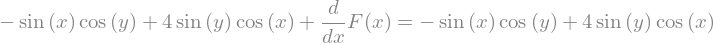

In [43]:
# form the Eq for step 2 above
ODEpsiF = sp.Eq(sp.integrate(vx.diff(x), y)+F(x).diff(x), -vy)
ODEpsiF
# if you want SymPy to apply so trig identities etc, try
#ODEpsiF.simplify()

The streamfunction is always defined up to a constant of integration, which we can drop or set any way we want. It only affects the values of $\psi$ corresponding to given streamlines, via $\psi(x,y) = const.$, but these values are arbitrary! So, we can impose $F(0)=0$ without loss of generality.

In [44]:
myF = sp.dsolve(ODEpsiF, ics={F(0): 0})
myF.simplify()

In [45]:
# put psi together via the Eq in step 1 above
psi = sp.expand(sp.simplify(sp.integrate(vx, y) + myF.rhs))

# let's display what we got
display(Math(r'\psi(x,y)=' + sp.latex(psi)))

<IPython.core.display.Math object>

In [46]:
# finally, we also 'lambdify' the streamfunction for evaluation
lam_psi = sp.lambdify([x, y], psi)

## Visualize $\psi$

### 3D surface plot

"Level sets" of the streamfunctions are curves, $y(x)$ in the plane, such that $\psi\big(x,y(x)\big) = const.$ for various values of the constant. The curves, $y(x)$, are the _streamlines_.

The streamfunction itself can be shown in a surface plot, and we can show the streamlines (the "level sets" of $\psi$) as contours, all in one plot, as in this [example](https://matplotlib.org/stable/gallery/mplot3d/contour3d_3.html).

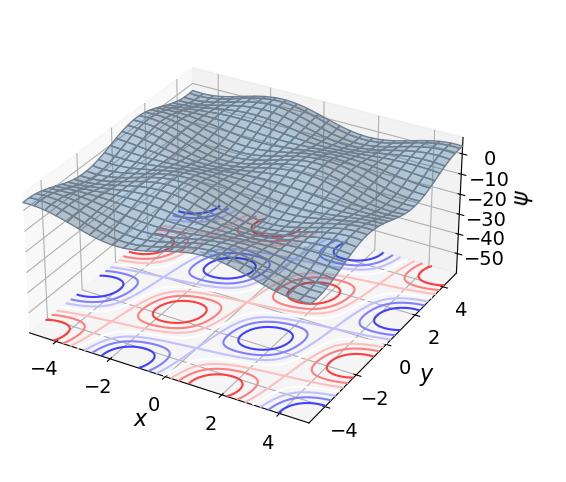

In [47]:
from mpl_toolkits.mplot3d import axes3d

fig = plt.figure(figsize=(10, 6), constrained_layout=False)
gs = fig.add_gridspec(1, 2, width_ratios=[100, 1], wspace=0.0)


# create two subplots: one for the 3D surface and one for whitespace padding
ax = fig.add_subplot(gs[0, 0], projection='3d')
ax_pad = fig.add_subplot(gs[0, 1])
ax_pad.axis('off')  # just whitespace
# clean up some of the whitespace on the right 
fig.subplots_adjust(right=0.75)

# evaluate the streamfunction on the meshgrid
zp = lam_psi(xp, yp)

# plot the 3D surface corresponding to z = psi(x,y)
ax.plot_surface(xp, yp, zp,
                edgecolor='slategray',  # surface color
                rstride=7, cstride=8,   # how many slats to show in meshframe
                alpha=0.3)              # transparency of surface

# plot projections of the contours for onto z direction dimension;
# choosing an 'offset' and the appropriate axes limits,
# the projected contours will sit on the 'walls' of the graph
my_offset = -15*min(np.abs(np.min(zp)),np.abs(np.max(zp)))
ax.contour(xp, yp, zp, zdir='z', offset=my_offset, cmap='bwr')

ax.set(xlim=(-max, max), 
       ylim=(-max, max), 
       zlim=(my_offset, 2*np.max(zp)),
       xlabel='$x$', ylabel='$y$', zlabel=r'$\psi$')
ax.set_zlabel(r'$\psi$', labelpad=6)

# make plot wider horizontally and zoom in a little to fill the white space
ax.set_box_aspect(aspect=(2, 2, 1), zoom=1)

plt.show()

### 2D contour plot

To better see the streamlines, that is the curves in the $(x,y)$ plane for constant $\psi(x,y)$, we can also directly use [`contour`](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html) from Matplotlib.

You can also try [`contourf`](https://matplotlib.org/stable/gallery/images_contours_and_fields/contourf_demo.html) on your own.

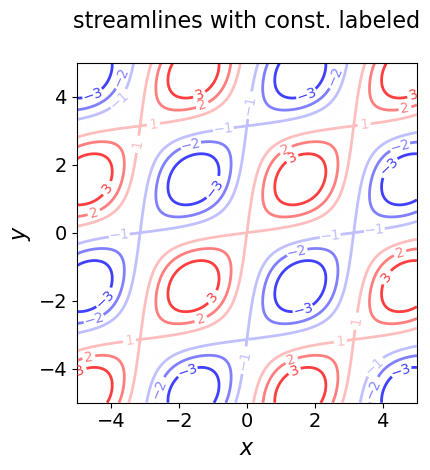

In [48]:
fig, ax = plt.subplots(tight_layout=True)

zp = lam_psi(xp, yp)

# you can specify the values of the 'const.'s in psi(x,y) = const.
# or let it choose its own by not passing this argument
consts = [0, 1, 3, 5, 7, 10, 15, 20]

strm = ax.contour(xp, yp, zp,  # consts,
                  # note this function takes linewidthS, plural...
                  linewidths=2,
                  cmap='bwr')

ax.clabel(strm, inline=True, fontsize=10)

ax.set_title('streamlines with ''const.'' labeled')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

In this plot, I used a [diverging colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html#diverging) to better highlight the regions of $\psi > 0$, $\psi = 0$, and $\psi < 0$.

### Interactive plot to understand "level sets"

In [65]:
def plot_one_streamline(const_value):
    fig = plt.figure(tight_layout=True, figsize=(12.8, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1.0])
    ax3d = fig.add_subplot(gs[0, 0], projection='3d')
    ax = fig.add_subplot(gs[0, 1])

    zp = lam_psi(xp, yp)
    
    # left: streamfunction surface and the cutting plane psi = const_value
    ax3d.plot_surface(xp, yp, zp,
                      edgecolor='none', color='teal',
                      alpha=0.4,
                      zorder=20)
    
    ax3d.plot_surface(xp, yp, const_value*np.ones_like(zp),
                      color='#8B6914', shade=False,
                      alpha=0.25,
                      zorder=10)
    
    # explicit intersection curve psi(x,y)=const_value to remove ambiguity
    ax3d.contour(xp, yp, zp,
                 levels=[const_value],
                 colors='darkgoldenrod',
                 linewidths=3,
                 zorder=1)
    
    #ax3d.computed_zorder = False
    ax3d.set(xlim=(-1.1*max, 1.1*max), ylim=(-1.1*max, 1.1*max),
             zlim=(2*np.min(zp), 2*np.max(zp)),
             xlabel='$x$', ylabel='$y$', zlabel=r'$\psi$')
    ax3d.set_box_aspect((1.1, 1, 0.9), zoom=1.25)
    # may require tweaking for different cases
    ax3d.view_init(elev=22, azim=-60)
    
    # remove default backing panes and grid for better 3D visualization
    ax3d.xaxis.pane.fill = False
    ax3d.yaxis.pane.fill = False
    ax3d.zaxis.pane.fill = False
    ax3d.grid(False)
    
    # right: plot our chosen streamline with a thicker line and a different color
    strm = ax.contour(xp, yp, zp,
                      levels=[const_value],
                      linewidths=3,
                      colors='darkgoldenrod')
    
    # show velocity field in the background using quiver arrows
    ax.quiver(xp[::nskip, ::nskip], yp[::nskip, ::nskip],
              lam_vx(xp, yp)[::nskip, ::nskip],
              lam_vy(xp, yp)[::nskip, ::nskip],
              scale=max, scale_units='xy',
              color='blue')
    
    #ax.set_title(rf'highlighting streamline $\psi = {const_value}$')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_aspect('equal')
    ax.set_xlim(-max, max)
    ax.set_ylim(-max, max)

    plt.show()

First, a static plot.

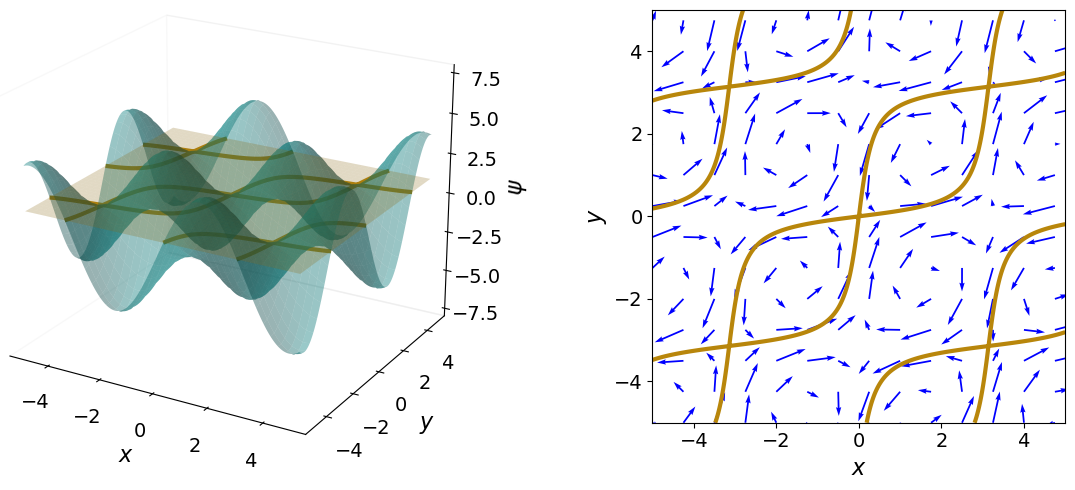

In [66]:
plot_one_streamline(1.0)

Then, an interactive plot to vary the constant used in $\psi(x,y)=const.$

In [67]:
interact(plot_one_streamline, 
         const_value=widgets.FloatSlider(value=0, 
                                         min=1.25*np.min(zp), 
                                         max=1.25*np.max(zp), 
                                         step=0.25,
                                         description='value, ψ ='));

## Visualize using a streamplot to compare

The streamlines, $y(x)$, are not only solutions of $\psi\big(x,y(x)\big)=const.$ for some value of the "const.", but also solutions to the differential equation
$$
  \frac{dy}{dx} = \frac{v_y}{v_x},\qquad y(x_0)=y_0,
$$
where the "initial condition" is the starting point, $(x_0,y_0)$, of the streamline and it is related to the "const." above.

This ODE for the streamlines can be solved, for many different values of $(x_0,y_0)$, plotting the resulting curves. That's exactly what [`streamplot`](https://matplotlib.org/stable/gallery/images_contours_and_fields/plot_streamplot.html#sphx-glr-gallery-images-contours-and-fields-plot-streamplot-py) does, solving this ODE numerically.

The result should look similar to the contour plot of $\psi$.

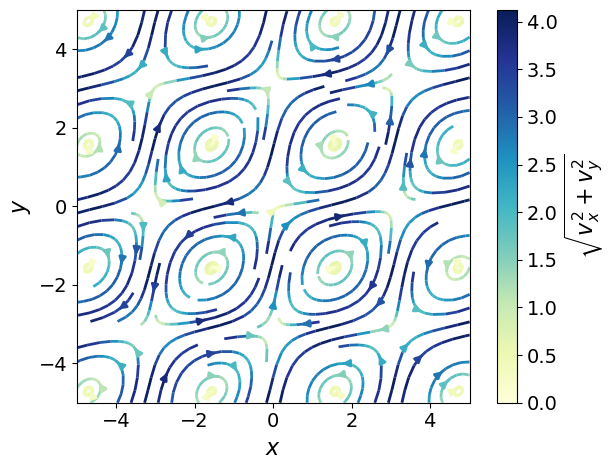

In [52]:
fig, ax = plt.subplots(tight_layout=True)

# plot the streamlines using a 'sequential' color map since the
# velocity magnitude used to color them is always > 0
strm = ax.streamplot(xp, yp, lam_vx(xp, yp), lam_vy(xp, yp),
                     linewidth=2,
                     color=np.sqrt(lam_vx(xp, yp)**2 + lam_vy(xp, yp)**2),
                     cmap='YlGnBu')  # or YlGnBu_r

plt.colorbar(strm.lines, label=r'$\sqrt{v_x^2+v_y^2}$')

ax.set_xlim((-max,max))
ax.set_ylim((-max,max))
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

This plot is nicer because it indicates the sense flow, and the magnitude of velocity via the colors, in addition to showing the streamlines.

For a streamplot, it is good to use a [sequential colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential) since we use the velocity magnitude (always positive) to color the streamlines. Here, lighter colors = slower flow.

# ADVANCED TOPICS ON STREAMFUNCTIONS IN 2D

## The vector potential

The Helmholtz decomposition theorem tells us that any _incompressible_ flow field $\underline{v}$ (that is, $\nabla\cdot\underline{v}=0$) can be expressed in terms of a [_vector potential_](https://en.wikipedia.org/wiki/Vector_potential) $\underline{A}$ as
$$
    \underline{v} = \nabla \times \underline{A}.
$$
Claim: the existence of a streamfunction and the streamfunction-velocity relations above come from theorem if we let 
$$
    \underline{A} = \psi(x,y) \underline{e}_z.
$$

Let's check this in general.

In [53]:
# grab a Cartesian coordinate system for vector calculus operations
c = CoordSys3D('c')

# c.x, c.y, c.z are the coordinate variables in this system
psi_gen = sp.Function('psi')(c.x, c.y)
# c.i, c.j, c.k are the unit vectors in x,y,z directions
A_gen = psi_gen*c.k

# calculate the generic v field as curl A
v_gen = curl(A_gen)
# grab x, y components, "&" means dot product in SymPy
vx_gen = sp.simplify((v_gen & c.i).subs({c.x: x, c.y: y}))
vy_gen = sp.simplify((v_gen & c.j).subs({c.x: x, c.y: y}))

display(Math(r'\text{Let:}~~\underline{A} = ' 
             + sp.latex(A_gen.subs({c.x: x, c.y: y}))))
display(Math(r'\text{Compute:}~~\underline{v} = \nabla\times\underline{A} = ' 
             + sp.latex(curl(A_gen).subs({c.x: x, c.y: y}))))
display(Math(r'\text{Thus:}~~v_x = ' + sp.latex(sp.simplify(vx_gen))
             + r'~~\text{and}~~v_y = ' + sp.latex(sp.simplify(vy_gen))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Let's check it for the chosen velocity field above.

In [54]:
# calculate curl A based on our streamfunction above
my_A = psi.subs({x: c.x, y: c.y})*c.k
# grab x, y components
my_vx = curl(my_A) & c.i
my_vy = curl(my_A) & c.j

display(Math(r'\text{Compute:}~~\underline{v} = \nabla\times\underline{A} = ' 
             + sp.latex(curl(my_A).subs({c.x: x, c.y: y}))))
display(Math(r'\text{Thus:}~v_x = ' 
             + sp.latex(sp.simplify(my_vx).subs({c.x: x, c.y: y}))))
display(Math(r'\text{Thus:}~v_y = ' 
             + sp.latex(sp.simplify(my_vy).subs({c.x: x, c.y: y}))))
display(Math(r'\text{Verify:}~~\text{found}~v_x - \text{given}~v_x = ' 
             + sp.latex(sp.simplify(vx - psi.diff(y))) + r'~~~\checkmark'))
display(Math(r'\text{Verify:}~~\text{found}~v_y - \text{given}~v_y = ' 
             + sp.latex(sp.simplify(vy + psi.diff(x))) + r'~~~\checkmark'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## The vorticity field

In 2D, we can compute the vorticity field $\underline{\omega}$ from the streamfunction $\psi$. 

This fact follows from evaluating $\underline{\omega}$ via the velocity field $\underline{v}$ given in terms of the vector potential $\underline{A}$. 

Specifically, 
$$
    \underline{\omega} = \nabla \times \underline{v} = \nabla \times \nabla \times \underline{A} = (-\nabla^2\psi) \underline{e}_z.
$$

Let's check this in general.

In [55]:
w_gen = curl(curl(A_gen))

display(Math(r'\underline{\omega} = \nabla\times\nabla\times\underline{A} = ' 
             + sp.latex(w_gen.subs({c.x: x, c.y: y}))))

display(Math(r'\nabla^2 \psi = ' 
             + sp.latex((psi_gen.diff(c.x,2) + psi_gen.diff(c.y,2)).subs({c.x: x, c.y: y}))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Let's check it for the chosen velocity field above.

In [56]:
my_w = sp.simplify(curl(curl(my_A)))
my_lapl_psi = sp.simplify(psi.diff(x,2) + psi.diff(y,2))
# you could also computed the Laplacian from its definiont as "div grad" 
# but need to sub the coordinates from c and then resub our x, y back at the end
#my_lapl_psi = sp.simplify(divergence(gradient(psi.subs({x: c.x, y: c.y})))).subs({c.x: x, c.y: y})

display(Math(r'\underline{\omega} = \nabla\times\nabla\times\underline{A} = ' 
             + sp.latex(my_w.subs({c.x: x, c.y: y}))))
display(Math(r'\nabla^2 \psi = ' 
             + sp.latex(my_lapl_psi)))
display(Math(r'\text{Verify:}~~\omega_z + \nabla^2 \psi = ' 
             + sp.latex(sp.simplify((my_w & c.k).subs({c.x: x, c.y: y}) + my_lapl_psi))
             + r'~~~\checkmark'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Finally, we can plot the vorticity distribution for our chosen field. 

**Note:** the vorticity may be zero everywhere if we chose an "ideal" (that is, irrotational) flow field. 🙂

In [57]:
# lambdify the vorticity for evaluation

# gracefully handle case when it is constant (independent of x, y)
depends_on_xy = len(my_lapl_psi.free_symbols.intersection({x, y})) > 0

if depends_on_xy:
    lam_wz = sp.lambdify([x, y], -my_lapl_psi)
else:
    def lam_wz(x,y):
        return np.full_like(x, fill_value=-my_lapl_psi)

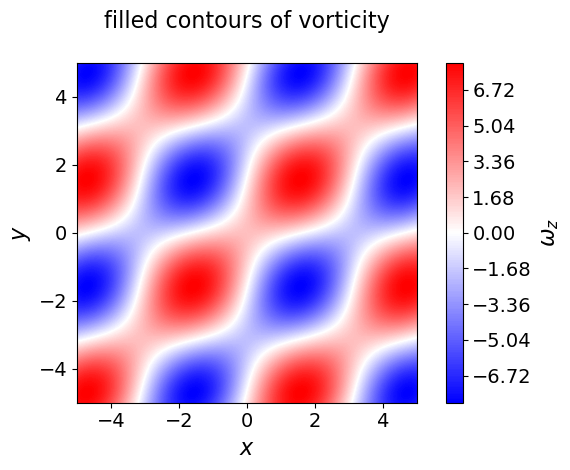

In [58]:
fig, ax = plt.subplots(tight_layout=True)
ax.set_title('filled contours of vorticity')

zp = lam_wz(xp, yp)

# use filled contours, otherwise constant omega_z is a problem
# show as many levels as points we have, to make it very smooth
ctrf = ax.contourf(xp, yp, zp, levels=zp.shape[0], cmap='bwr')

cbar = fig.colorbar(ctrf, ax=ax) # pad=0.02
cbar.set_label(r'$\omega_z$')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')